## Bias modelling
-----------------

In this notebook, we take a look at modelling the galaxy and magnification biases for each of the tracers.

In [2]:
import numpy as np 
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.sgp as sgp

In [4]:
hsc_bins = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]

# naming conventions
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

## Spectroscopic tracer galaxy bias
-----------------------------------

We fit a polynomial to the measured galaxy bias and compare with formulas given by Enrique Paillas & Edmond Chaussidon.

In [5]:
def bias_evolution(z, tracer='QSO'):
    """
    Bias model fitted from DR1 unblinded data (the formula from Laurent et al. 2016 (1705.04718))
    """
    if tracer == 'QSO':
        alpha = 0.237
        beta = 2.328
    elif tracer == 'LRG':
        alpha = 0.209
        beta = 2.790
    elif tracer == 'ELG_LOPnotqso':
        alpha = 0.153
        beta = 1.541
    else:
        raise NotImplementedError(f'{tracer} not implemented.')
    return alpha * ((1+z)**2 - 6.565) + beta

In [10]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
stem = 'v10'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
assert all([p.exists() for p in path_dictionary.values()])
autofr = cf.CorrFileReader(path_dictionary["DESI_NGC"])

In [ ]:
importlib.reload(inference)
bss = {t:[] for t in tracers}
bss_err = {t:[] for t in tracers}
tvalues = {}
for t in tracers:
    tbin = autofr.get_bins(t)
    tval = (tbin[1:] + tbin[:-1])/2
    tvalues[t] = tval
    dz = np.mean(np.diff(tbin))
    for zind, z in enumerate(tval, start=1):
        w, we, cs = inference.wss(
            bin_index1=zind,
            bin_index2=zind,
            tracer1=t,
            tracer2=t,
            path_NGC=path_dictionary['DESI_NGC'],
            path_SGC=path_dictionary['DESI_SGC'],
            scale_cuts=[.2, 3],
        )
        ang = ct.hMpc2arcsec(cs, z) / 3600
        dndz = np.zeros(len(tval))
        dndz[zind - 1] = 1.0 / dz
        wdm = ct.get_wDM(
            angular_bins=ang,
            zbin_edges=tbin,
            dndz=dndz
        )
        ## integrate wDM to get the effective wDM over angular scales
        weights = cs**(-1)
        weights /= np.trapz(weights, x=cs)
        wdm_eff = np.trapz(np.multiply(wdm, weights), x=cs)
        bss[t].append(np.sqrt(w/wdm_eff))
        bss_err[t].append(np.sqrt(we/wdm_eff))

Bias evolution for BGS_ANY not implemented, skipping.
Bias evolution for ELGnotqso not implemented, skipping.


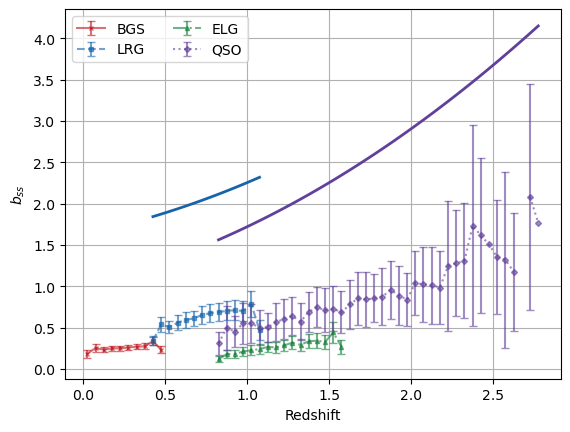

In [64]:
for t in tracers:
    bss[t] = np.array(bss[t])
    bss_err[t] = np.array(bss_err[t])
    tvalues[t] = np.array(tvalues[t])
    indt = tracers.index(t)
    plt.errorbar(
        tvalues[t],
        bss[t], 
        yerr=bss_err[t], 
        marker=markers[indt],
        markersize=3,
        label=tracer_trad[t], 
        color=colors[indt],
        linestyle=linestyles[indt], 
        capsize=3,
        alpha=0.6,
    )
    try:
        plt.plot(
            tvalues[t], 
            bias_evolution(tvalues[t], tracer=t), 
            color=colors[indt], 
            linestyle='-', 
            linewidth=2,
        )
    except NotImplementedError:
        print(f'Bias evolution for {t} not implemented, skipping.')
plt.xlabel('Redshift')
plt.ylabel(r'$b_{ss}$')
plt.legend(
    loc='upper left', 
    ncol=2, 
    fontsize=10,
)
plt.grid()